## 美国核电产能与趋势分析

本研究以美国近年来核电产能以及使用趋势的研究数据为基础，对美国的核电产业进行数据化分析项目重点为
* 年度核电产值与使用的变化率
* 各地区的核电使用情况及其变化率
* 产业结构分析
* 总体产业分析

**一，获取数据**

In [12]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 获取美国核电数据，通过获取其API调用数据

API_KEY = "4uHzt4DHXkT6q7VThHzMRMkE6oF7bCZlq1lnkjia"

url = "https://api.eia.gov/v2/electricity/electric-power-operational-data/data/"
params = {
    "api_key": API_KEY,
    "data[0]": "generation",
    "frequency": "annual",
    "facets[fueltypeid][]": "NUC",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "length": 2000
}

response = requests.get(url, params=params)
data = response.json()
records = data['response']['data']

df = pd.DataFrame(records)
df = df[['period', 'location', 'stateDescription', 'sectorid', 'sectorDescription',
         'fueltypeid', 'fuelTypeDescription', 'generation', 'generation-units']]

df.to_csv('U202515697.csv', index=False, encoding='utf-8-sig')

**二，美国核电总体趋势分析**

1. 美国年度总产值基本情况以及最值分析

In [13]:
df = pd.read_csv('U202515697.csv')
df_US = df[(df['location'] == 'US') & (df['sectorid'] == 99)]
arr_US = np.array(df_US['generation'])
print(arr_US)

[784780.718   781865.31    774873.169   771537.17649 779644.595
 789878.863   809409.262   807084.477   804949.635   805693.948
 797177.877  ]


In [14]:
print(f"最近{len(arr_US)}年来美国核电全产业的总产值为{np.sum(arr_US)}千兆瓦时，"
      f"其中总产值最大的为{np.max(arr_US)}千兆瓦时，为{2025-np.argmax(arr_US)}年产值")

最近11年来美国核电全产业的总产值为8706895.03049千兆瓦时，其中总产值最大的为809409.262千兆瓦时，为2019年产值


2. 美国年度总产值趋势分析以及折线图绘制

In [15]:
x = []
y = []

for i in range(len(arr_US)):
    year = 2025 - (len(arr_US) - ( i + 1))
    x.append(year)
    y.append(arr_US[len(arr_US) - (i + 1)])

print(x,y)

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] [np.float64(797177.877), np.float64(805693.948), np.float64(804949.635), np.float64(807084.477), np.float64(809409.262), np.float64(789878.863), np.float64(779644.595), np.float64(771537.17649), np.float64(774873.169), np.float64(781865.31), np.float64(784780.718)]


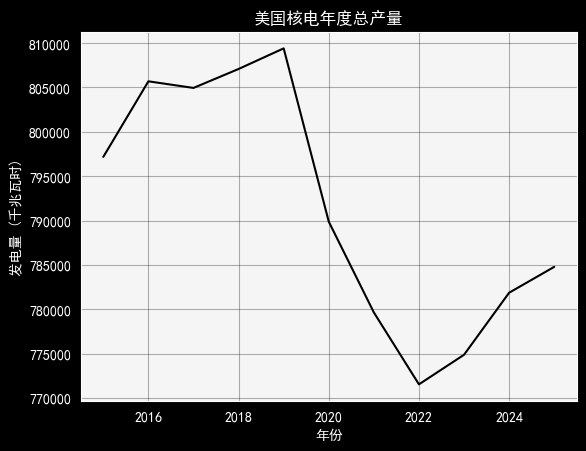

In [16]:
plt.plot(x, y, linestyle='-', color='black')
plt.gca().set_facecolor('#f5f5f5')
plt.title('美国核电年度总产量')
plt.xlabel('年份')
plt.ylabel('发电量 (千兆瓦时)')
plt.grid(True, alpha=0.3,color='black')
plt.show()

3. 年度同比增长率计算

In [17]:
growth_rate = []
values = np.array(df_US['generation'])

for i in range(1,len(arr_US)):
    rate = (values[i] - values[i-1])/values[i-1]*100
    growth_rate.append(rate)

years = np.array(x)
for i in range(0,len(years)-1):
    print(f"{years[i]}年的同比增长率为：{growth_rate[i]:.2f}%")


2015年的同比增长率为：-0.37%
2016年的同比增长率为：-0.89%
2017年的同比增长率为：-0.43%
2018年的同比增长率为：1.05%
2019年的同比增长率为：1.31%
2020年的同比增长率为：2.47%
2021年的同比增长率为：-0.29%
2022年的同比增长率为：-0.26%
2023年的同比增长率为：0.09%
2024年的同比增长率为：-1.06%


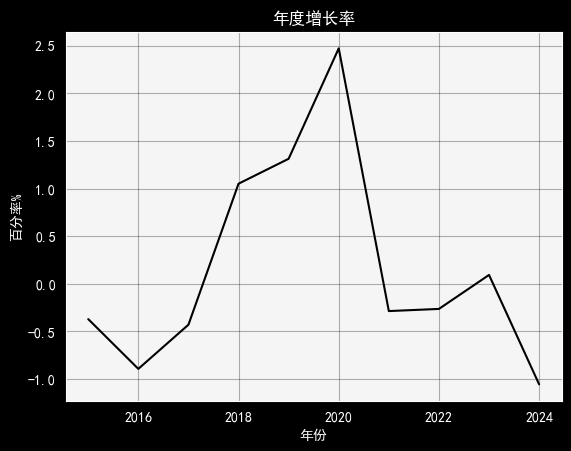

In [27]:
plt_years = years[:-1]
plt.plot(plt_years,growth_rate,linestyle='-', color='black')
plt.gca().set_facecolor('#f5f5f5')
plt.title('年度增长率')
plt.xlabel("年份")
plt.ylabel("百分率%")
plt.grid(True, alpha=0.3,color='black')
plt.show()

**二，各地区核电产能分析**

1. 各地区核电产能排位分析

In [ ]:
'''
    AL 阿拉巴马州
    ENC 东北中部地区
    SAT 南大西洋地区
    90 太平洋地区
'''

df = pd.read_csv('U202515697.csv')
df_AL = df[(df['location'] == 'AL') & (df['sectorid'] == 99)]
df_ENC = df[(df['location'] == 'ENC') & (df['sectorid'] == 99)]
df_SAT = df[(df['location'] == 'SAT') & (df['sectorid'] == 99)]
df_90 = df[(df['location'] == '90') & (df['sectorid'] == 99)]

arr_AL = np.array(df_AL['generation'])
arr_ENC = np.array(df_ENC['generation'])
arr_SAT = np.array(df_SAT['generation'])
arr_90 = np.array(df_90['generation'])

arr_states = np.array([np.sum(arr_AL),np.sum(arr_ENC), np.sum(arr_SAT), np.sum(arr_90)])

dict_states = {
    0:'AL',
    1:'ENC',
    2: 'SAT',
    3: '90',
}

print(f"四个地区中近十年综合最高产量为{np.max(arr_states):.2f},为{dict_states[np.argmax(arr_states)]}地区")

In [ ]:
# 定义计算市场份额的函数 方便后续调用以及数据分析
dict_states_generation = {
    'AL':arr_states[0],
    'ENC':arr_states[1],
    'SAT':arr_states[2],
    '90':arr_states[3],
}

def sum_generation(arr):
    return np.sum(arr)

def market_shares(generation,arr):
    return generation/sum_generation(arr)*100

market_share = []
for key,value in dict_states_generation.items():
    print(f"{key}地区近十年时间内生产总额在全美市场中的占比为{market_shares(value,arr_states):.2f}%")
    market_share.append(round(market_shares(value,arr_states),2))

In [ ]:
labels = list(dict_states.values())
sizes = market_share

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12}
)
plt.title('各地区核电产量占比', fontsize=14)
plt.show()